# Analysis of Global Scientific Production (2000–2024)

In this notebook, we examine the scientific output of the 15 most productive countries according to Scimago Journal & Country Rank (https://www.scimagojr.com/countryrank.php). Using data obtained through the OpenAlex API (https://openalex.org), Scopus and Web Of Science, we collect the number of published scientific articles per year from 2000 to 2024 for each country.

The search in Scopus was "AFFILCOUNTRY(countryName) AND PUBYEAR > 1999 AND PUBYEAR < 2025". The search in Web Of Science was "CU=countryName and PY=(2000-2024)". The data can be accessed from https://github.com/cossorzano/COSS_DataAnalysis_notebooks/blob/main/Notebooks/dataPublications2024.zip

The analysis is performed in two complementary ways:
* Absolute production — the total number of articles published each year, showing the evolution of global research output and revealing how different countries have contributed to its growth.

* Normalized production — each country’s publication counts are divided by their respective 2021 value, allowing comparison of relative growth trends independently of total size.

Finally, we compute the median normalized profile across all countries to obtain a representative global trend of scientific production over the past 25 years.

## Results

The median curve shows a distinct **rise-and-fall** pattern in global scientific production between 2000 and 2024.

From 2000 to around 2020, the normalized median number of articles increases steadily, with an average annual growth rate of about 3.5 % (slope = 0.035). This long ascent reflects a broad expansion of worldwide research capacity, increased international collaboration, and the continuous growth of indexed journals and research funding.

After peaking near 2021, the trend reverses: the normalized median declines with an average annual decrease of roughly 3.5 % (slope = –0.035). This downturn points to a contraction following two decades of rapid growth. Possible causes include the COVID-19 pandemic’s disruption of research activity, changes in publication incentives, and a slowdown in funding growth in some major economies.

Overall, the curve captures a 20-year phase of expansion followed by a recent and sharper decline, indicating that the remarkable rise in global scientific production that characterized the early 21st century has begun to recede in the most recent years.

In [1]:
import os
import csv
import glob
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data from OpenAlex

In [2]:
def getWorksFromCountryAll(country):
  base = "https://api.openalex.org/works"
  params = {
      # institution lineage, type=article, and year range
      "filter": f"authorships.institutions.country_code:{country},type:article,publication_year:2000-2024",
      # be nice to their API
      "mailto": "coss@cnb.csic.es",
      # group counts by year
      "group_by": "publication_year",
      # large page size to return all groups in one shot
      "per_page": 200,
  }

  r = requests.get(base, params=params, timeout=60)
  r.raise_for_status()
  data = r.json()

  # The response has groups with {"key": "YYYY", "count": N}
  groups = data.get("group_by") or data  # some clients show a bare list; handle both
  df = pd.DataFrame(groups)
  df["year"] = df["key"].astype(int)
  df = df.sort_values("year", ascending=True)[["year", "count"]].reset_index(drop=True)

  return df

In [3]:
worksOA={}
worksOA["US"]=getWorksFromCountryAll("US")
worksOA["CN"]=getWorksFromCountryAll("CN")
worksOA["GB"]=getWorksFromCountryAll("GB")
worksOA["DE"]=getWorksFromCountryAll("DE")
worksOA["JP"]=getWorksFromCountryAll("JP")
worksOA["IN"]=getWorksFromCountryAll("IN")
worksOA["FR"]=getWorksFromCountryAll("FR")
worksOA["IT"]=getWorksFromCountryAll("IT")
worksOA["CA"]=getWorksFromCountryAll("CA")
worksOA["AU"]=getWorksFromCountryAll("AU")
worksOA["ES"]=getWorksFromCountryAll("ES")
worksOA["RU"]=getWorksFromCountryAll("RU")
worksOA["KR"]=getWorksFromCountryAll("KR")
worksOA["BR"]=getWorksFromCountryAll("BR")
worksOA["NL"]=getWorksFromCountryAll("NL")

## Data from Scopus

In [4]:
def load_scopus(path, year_min=2000, year_max=2024):
    # Read all lines
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('"YEAR"'):
            start_idx = i + 1  # data starts on next line
            break

    if start_idx is None:
        raise ValueError('Could not find a line starting with "YEAR" in the file.')

    records = []
    for line in lines[start_idx:]:
        if not line.strip():
            continue  # skip empty lines
        row = next(csv.reader([line]))
        if len(row) < 2:
            continue
        year_str, count_str = row[0], row[1]
        try:
            year = int(year_str)
            count = int(count_str)
        except ValueError:
            continue  # skip lines that don't have numeric year/count
        if year_min <= year <= year_max:
            records.append({"year": year, "count": count})

    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values("year").reset_index(drop=True)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

    return df

worksSC = {}
for fn in glob.glob("Scopus*.csv"):
    country = os.path.splitext(fn)[0][-2:]
    df = load_scopus(fn)
    worksSC[country] = df

## Data from Web of Science

In [5]:
def load_WoS(fn):
    df = pd.read_excel(fn)

    df_filtered = (
        df.rename(columns={"Publication Years": "year", "Count": "count"})
          .query("2000 <= year <= 2024")
          .sort_values("year")
          .reset_index(drop=True)
    )
    return df_filtered

worksWoS = {}
for fn in glob.glob("WoS*.xlsx"):
    country = os.path.splitext(fn)[0][-2:]
    df = load_WoS(fn)
    worksWoS[country] = df

## Combined data

In [6]:
import pandas as pd

def build_combined_dict(worksOA, worksSC, worksWoS):
    worksAll = {}

    for cc in worksOA.keys():
        # 1) Rename counts for each source
        df_oa  = worksOA[cc].rename(columns={"count": "OA"})
        df_sc  = worksSC[cc].rename(columns={"count": "SC"})
        df_wos = worksWoS[cc].rename(columns={"count": "WoS"})

        # 2) Merge on 'year'
        df = df_oa.merge(df_sc, on="year", how="outer")
        df = df.merge(df_wos, on="year", how="outer")

        # Make sure years are sorted
        df = df.sort_values("year").reset_index(drop=True)

        # 3) Normalized counts (divide by 2021 value for each source)
        for col in ["OA", "SC", "WoS"]:
            # find value in 2021 (may be NaN if missing)
            base = df.loc[df["year"] == 2021, col].iloc[0] if (df["year"] == 2021).any() else None
            if base and base != 0:
                df[col + "_norm"] = df[col] / base
            else:
                df[col + "_norm"] = pd.NA  # or np.nan

        # 4) Medians per year (row-wise)
        df["median_abs"]  = df[["OA", "SC", "WoS"]].median(axis=1, skipna=True)
        df["median_norm"] = df[["OA_norm", "SC_norm", "WoS_norm"]].median(axis=1, skipna=True)

        # Store in the output dict
        worksAll[cc] = df

    return worksAll

worksAll = build_combined_dict(worksOA, worksSC, worksWoS)

In [7]:
for country in worksAll.keys():
    pd.set_option("display.width", 100)
    print(f"{country}:")
    print(worksAll[country])

US:
    year      OA      SC     WoS   OA_norm   SC_norm  WoS_norm  median_abs  median_norm
0   2000  368199  373467  470842  0.459489  0.476565  0.543435    373467.0     0.476565
1   2001  370894  376176  464083  0.462852  0.480022  0.535634    376176.0     0.480022
2   2002  509416  399671  480486  0.635719  0.510003  0.554566    480486.0     0.554566
3   2003  479299  445100  503644  0.598135  0.567973  0.581294    479299.0     0.581294
4   2004  478970  480022  530650  0.597724  0.612535  0.612464    480022.0     0.612464
5   2005  521787  533350  543779  0.651157  0.680585  0.627617    533350.0     0.651157
6   2006  545089  548873  566869  0.680236  0.700393  0.654267    548873.0     0.680236
7   2007  538820  555219  578817  0.672413  0.708491  0.668057    555219.0     0.672413
8   2008  567056  562008  595718  0.707650  0.717154  0.687564    567056.0     0.707650
9   2009  586407  597482  626974  0.731799  0.762421  0.723639    597482.0     0.731799
10  2010  622213  622656  63

## Plots

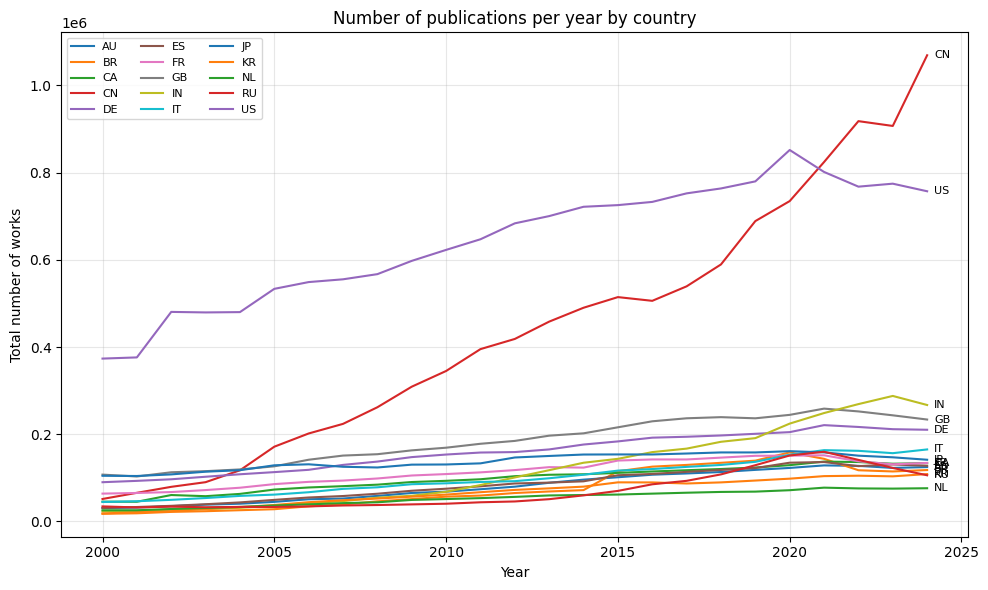

In [8]:
def plot_country_publications(country_dfs, title, ylabel, colName, labelPosition):
    plt.figure(figsize=(10,6))

    for country, df in sorted(country_dfs.items()):
        df_sorted = df.sort_values("year")
        plt.plot(df_sorted["year"], df_sorted[colName], label=country, linewidth=1.5)

        if labelPosition==1:
          # Add label at the end of the line (rightmost point)
          x = df_sorted["year"].iloc[-1]
          y = df_sorted[colName].iloc[-1]
          plt.text(x + 0.2, y, country, fontsize=8, va='center')
        elif labelPosition==-1:
          # Add label at the end of the line (leftmost point)
          x = df_sorted["year"].iloc[0]
          y = df_sorted[colName].iloc[0]
          plt.text(x - 0.8, y, country, fontsize=8, va='center')

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_country_publications(worksAll, "Number of publications per year by country",
                          "Total number of works", "median_abs", 1)

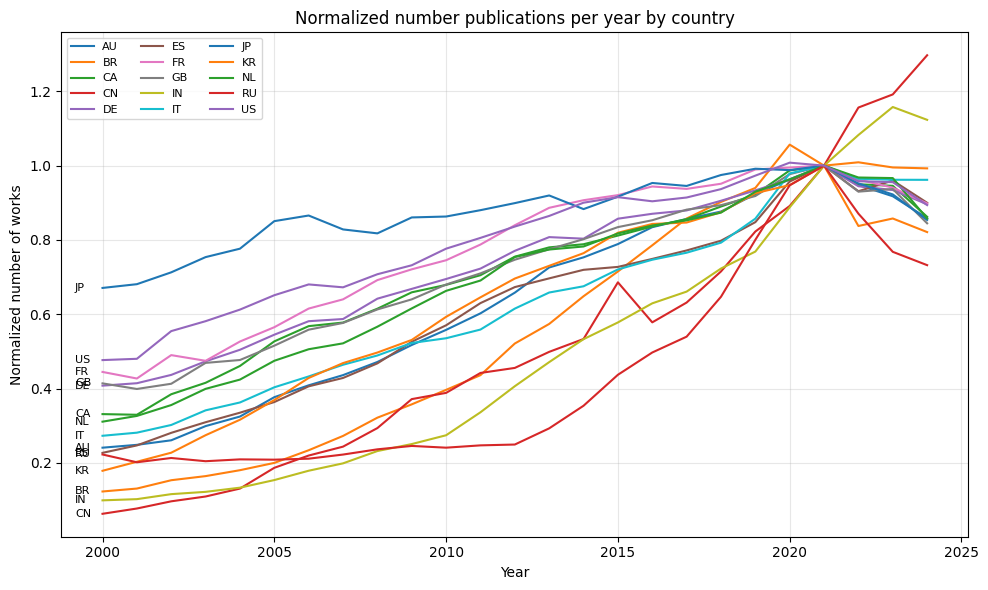

In [9]:
plot_country_publications(worksAll, "Normalized number publications per year by country",
                          "Normalized number of works", "median_norm", -1)

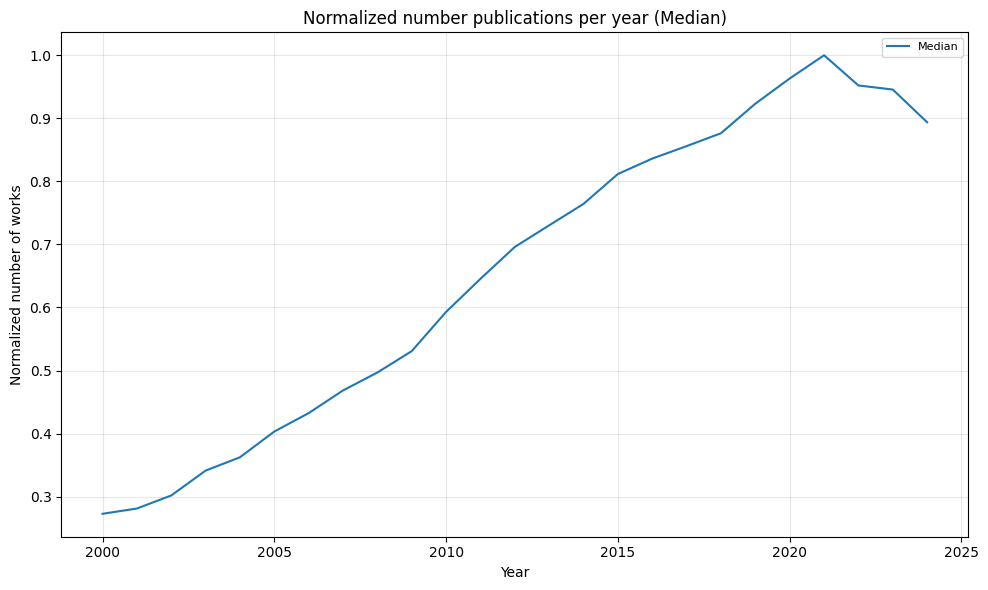

In [10]:
df_all = pd.concat(
    {country: df.set_index("year")["median_norm"] for country, df in worksAll.items()},
    axis=1
)

# Compute the median across countries for each year
median_per_year = df_all.median(axis=1, skipna=True)

# Optionally convert to a DataFrame for plotting or export
median_df = median_per_year.reset_index()
median_df.columns = ["year", "median_norm"]

worksMedian = {"Median": median_df}
plot_country_publications(worksMedian, "Normalized number publications per year (Median)",
                          "Normalized number of works", "median_norm", 0)

In [11]:
median_df

,year,median_norm
0,2000,0.272833
1,2001,0.281194
2,2002,0.301906
3,2003,0.341311
4,2004,0.362470
5,2005,0.403324
6,2006,0.432499
7,2007,0.468485
8,2008,0.496900
9,2009,0.530832


In [12]:
slopeUp=(median_df['median_norm'][21]-median_df['median_norm'][0])/21
slopeDown=(median_df['median_norm'][24]-median_df['median_norm'][21])/3
print(f"Slope up={slopeUp}; Slope down={slopeDown}")

Slope up=0.03462698639710235; Slope down=-0.03542093231365614


In [13]:
ratios = (pd.Series({c: (df.set_index("year").loc[2024, "median_norm"] / df.set_index("year").loc[2021, "median_norm"]-1)*100
                     for c, df in worksAll.items()})
          .sort_values(ascending=False))

print("Change from 2021 to 2024 (in %):")
print(ratios.round(1))
print(f"Mean = {ratios.mean():.1f}")

Change from 2021 to 2024 (in %):
CN    29.7
IN    12.3
KR    -0.7
IT    -3.8
ES   -10.0
FR   -10.2
DE   -10.4
US   -10.6
CA   -13.8
AU   -14.2
NL   -14.2
JP   -14.6
GB   -15.5
BR   -17.9
RU   -26.8
dtype: float64
Mean = -8.1


In [14]:
def years_lost_to_2024(df):
    s = df.set_index("year")["median_abs"].dropna()
    c2024 = s.loc[2024]
    prior = s.loc[s.index <= 2021]
    if prior.empty:
        return np.nan, np.nan
    y_closest = (prior - c2024).abs().idxmin()
    lost = 2024 - y_closest
    return int(lost), int(y_closest)

decliners = ratios[ratios < 0].index
lost_info = {
    c: years_lost_to_2024(worksAll[c]) for c in decliners
}

lost_df = (pd.DataFrame(lost_info, index=["years_lost","closest_year"])
             .T.sort_values("years_lost", ascending=False))

print(lost_df)
print(f"Mean = {lost_df['years_lost'].mean():.1f}")

    years_lost  closest_year
JP          12          2012
BR           9          2015
FR           9          2015
US           7          2017
RU           6          2018
GB           5          2019
ES           5          2019
DE           4          2020
AU           4          2020
IT           3          2021
KR           3          2021
NL           3          2021
CA           3          2021
Mean = 5.6
